# Task 1: DBSCAN Clustering
**Dataset:** weather_clean.csv — Raleigh-Durham Airport, 1,477 rows

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

df = pd.read_csv('weather_clean.csv')
print(f'Loaded: {df.shape[0]} rows x {df.shape[1]} cols')
df.describe().round(2)

Loaded: 1477 rows x 6 cols


,X1,X2,X3,X4,X5,Y
count,1477.00,1477.00,1477.00,1477.00,1477.00,1477.0
mean,73.82,52.23,0.13,5.90,0.01,62.6
std,15.51,15.87,0.36,2.89,0.09,15.0
min,29.00,10.00,0.00,0.45,0.00,19.0
25%,63.00,39.00,0.00,3.80,0.00,51.0
50%,75.00,54.00,0.00,5.37,0.00,65.0
75%,86.00,66.00,0.03,7.61,0.00,75.0
max,106.00,80.00,4.02,19.91,2.30,89.0


## Task 1.1

The full dataset has 1,477 points. Using , 1/10 sampling is used for scatter plots to reduce density.

Sampled 148 points (1/10 of 1477) for scatter plots


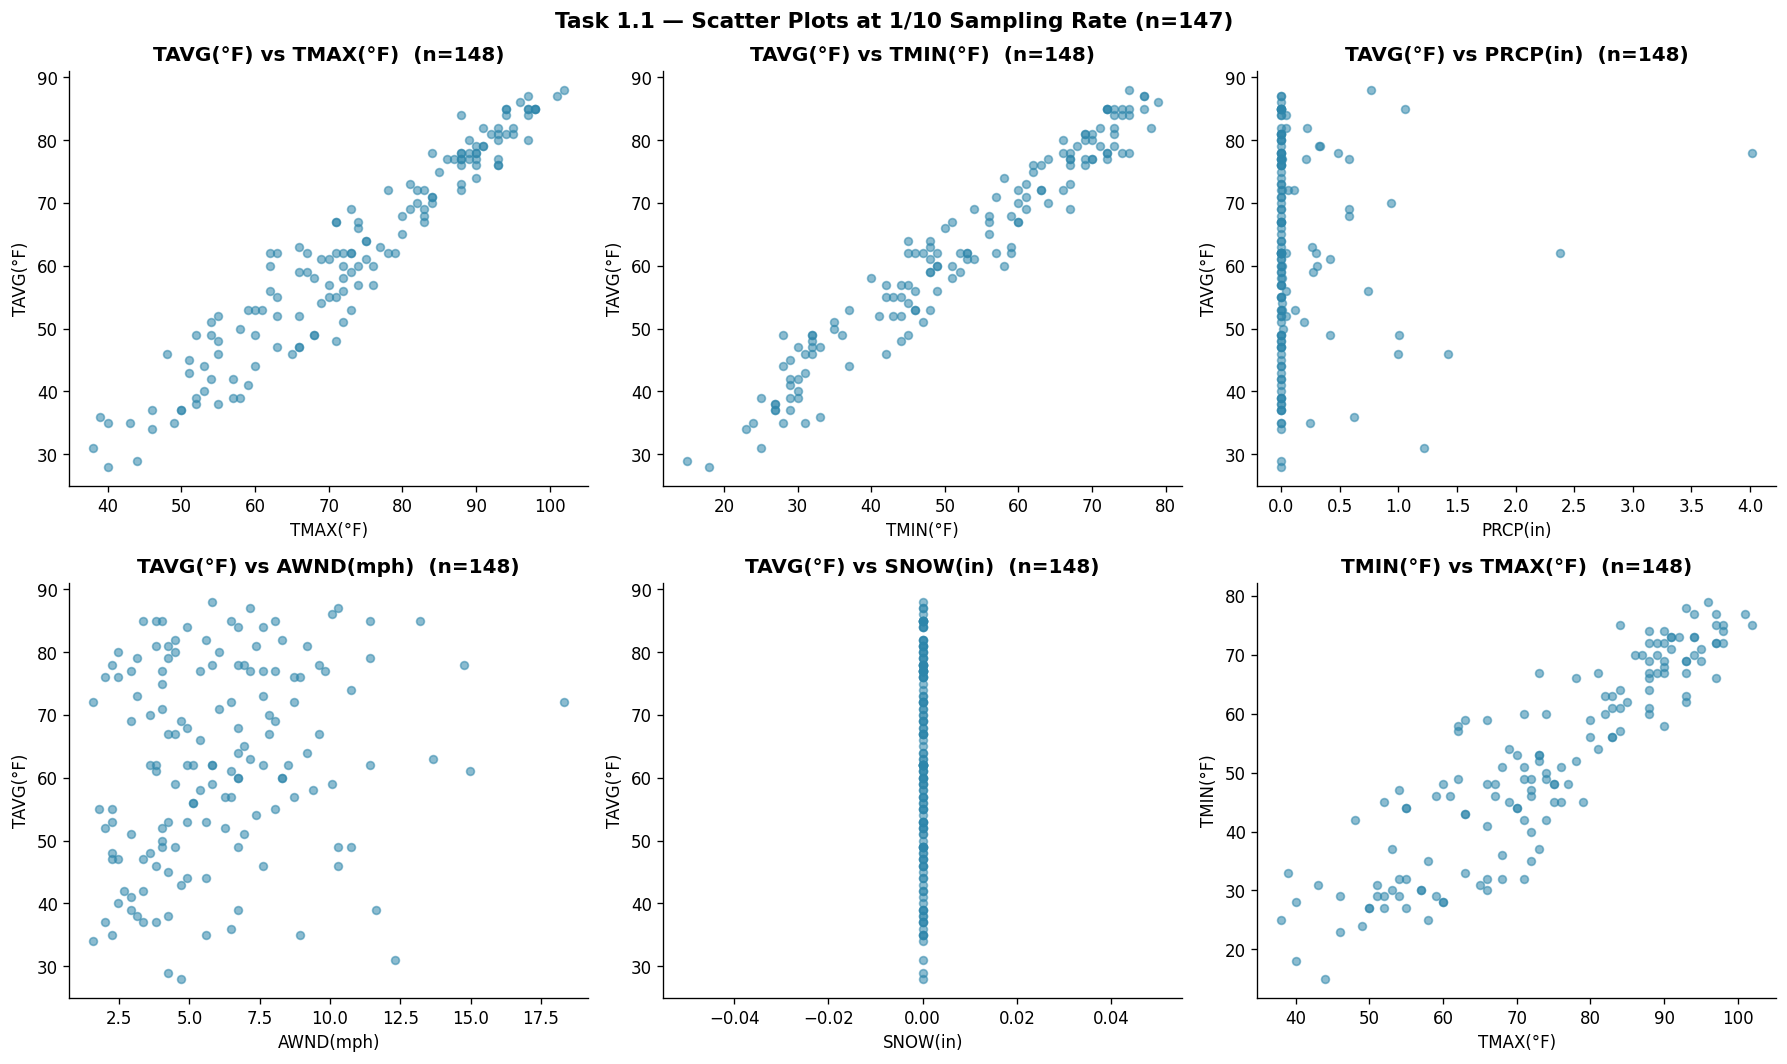

Y vs X1/X2: strong linear clusters.
Y vs X3/X5: zero-inflated.
X1 vs X2: collinear (r=0.93)


In [13]:
# 1/10 sampling — used for scatter plots only
df_sample = df.sample(frac=0.1, random_state=42)
print(f'Sampled {len(df_sample)} points (1/10 of {len(df)}) for scatter plots')

labels = {'X1':'TMAX(°F)','X2':'TMIN(°F)','X3':'PRCP(in)','X4':'AWND(mph)','X5':'SNOW(in)','Y':'TAVG(°F)'}
pairs  = [('X1','Y'),('X2','Y'),('X3','Y'),('X4','Y'),('X5','Y'),('X1','X2')]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

# Scatter plots use df_sample (not df) as specified
for i, (cx, cy) in enumerate(pairs):
    axes[i].scatter(df_sample[cx], df_sample[cy], alpha=0.55, s=22, color='#2E86AB')
    axes[i].set_xlabel(labels[cx])
    axes[i].set_ylabel(labels[cy])
    axes[i].set_title(f'{labels[cy]} vs {labels[cx]}  (n={len(df_sample)})', fontweight='bold')

fig.suptitle('Task 1.1 — Scatter Plots at 1/10 Sampling Rate (n=147)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('t1_scatter_sampled.png', dpi=150, bbox_inches='tight')
plt.show()
print('Y vs X1/X2: strong linear clusters.'\
'\nY vs X3/X5: zero-inflated.' \
'\nX1 vs X2: collinear (r=0.93)')

## Task 1.2

**Feature choice - Using TMAX + PRCP, not TMAX + TMIN:**  
TMAX (X1) and TMIN (X2) have r=0.93 — they are nearly perfectly collinear and collapse onto a 1D diagonal band in 2D space. DBSCAN returns 1 cluster for all eps values on this pair. TMAX + PRCP provides two genuinely independent dimensions (seasonal temperature vs rain intensity), revealing real density structure in the data.

**eps selection:** The k-distance plot guides eps choice via the elbow method.

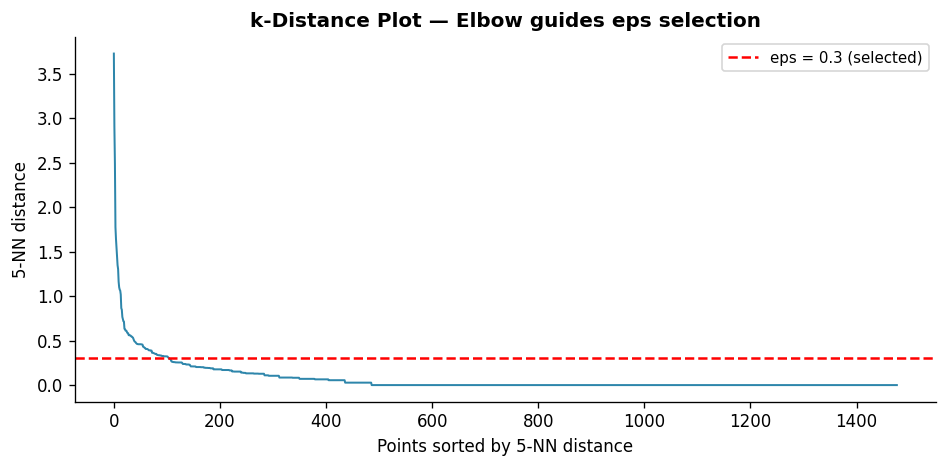

In [3]:
# Features: TMAX (X1) and PRCP (X3)
features = ['X1', 'X3']
X_full   = df[features].values         # full dataset for DBSCAN
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# k-distance plot
k    = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
dists, _ = nbrs.kneighbors(X_scaled)
k_dist   = np.sort(dists[:, k-1])[::-1]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_dist, color='#2E86AB', linewidth=1.2)
ax.axhline(0.3, color='red', linestyle='--', linewidth=1.5, label='eps = 0.3 (selected)')
ax.set_xlabel('Points sorted by 5-NN distance')
ax.set_ylabel('5-NN distance')
ax.set_title('k-Distance Plot — Elbow guides eps selection', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('t1_kdist.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
dbscan    = DBSCAN(eps=0.3, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise    = (labels_db == -1).sum()

print(f'DBSCAN  eps=0.3, min_samples=5, features=[TMAX, PRCP], n={len(df)}')
print(f'  Clusters : {n_clusters}')
print(f'  Noise    : {n_noise} ({100*n_noise/len(labels_db):.1f}%)')
print()

rows = []
for c in sorted(set(labels_db)):
    mask = labels_db == c
    sub  = df[mask]
    rows.append({'Label': 'Noise (-1)' if c==-1 else f'Cluster {c}',
                 'Count': mask.sum(),
                 'Mean TMAX (°F)': round(sub['X1'].mean(),1),
                 'Mean PRCP (in)': round(sub['X3'].mean(),3),
                 'Mean TAVG (°F)': round(sub['Y'].mean(),1)})
print(pd.DataFrame(rows).to_string(index=False))

DBSCAN  eps=0.3, min_samples=5, features=[TMAX, PRCP], n=1477
  Clusters : 3
  Noise    : 84 (5.7%)

     Label  Count  Mean TMAX (°F)  Mean PRCP (in)  Mean TAVG (°F)
Noise (-1)     84            70.8           1.306            63.1
 Cluster 0   1383            74.1           0.050            62.6
 Cluster 1      5            39.8           0.570            37.8
 Cluster 2      5            88.6           0.840            78.4


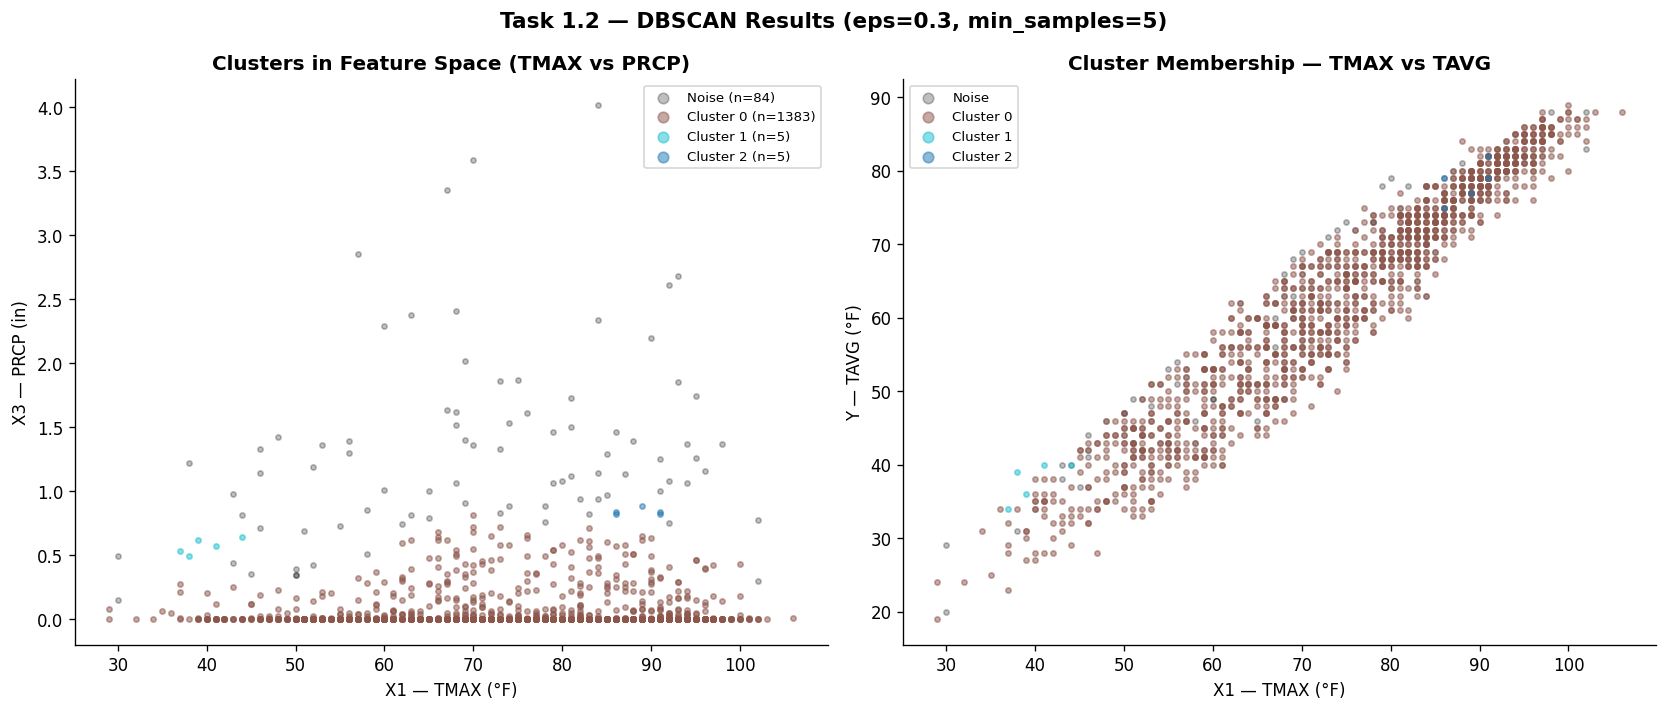

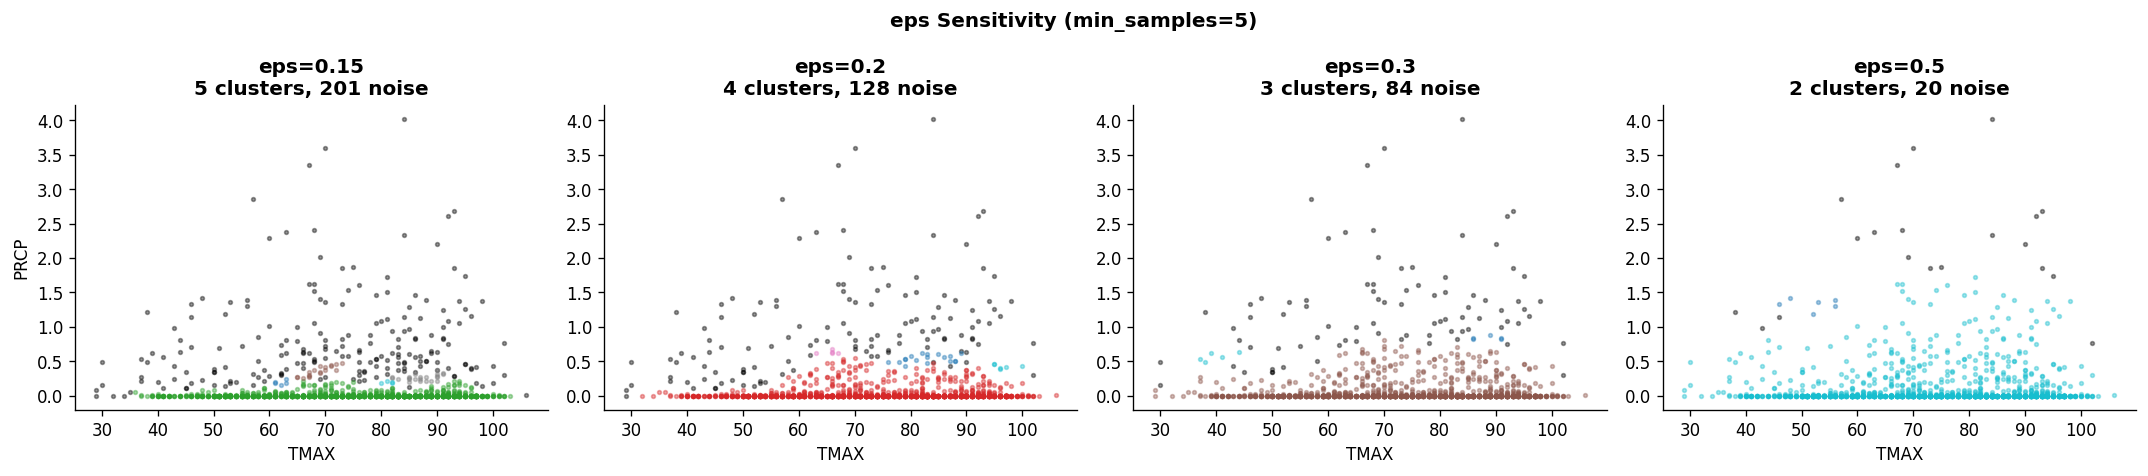

In [15]:
# Visualixing the clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
uniq   = sorted(set(labels_db))
pal    = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))

for idx, lbl in enumerate(uniq):
    mask  = labels_db == lbl
    color = 'black' if lbl == -1 else pal[idx % len(pal)]
    name  = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    alpha = 0.25 if lbl == -1 else 0.5

    axes[0].scatter(X_full[mask,0], X_full[mask,1], c=[color], s=10, alpha=alpha,
                    label=f'{name} (n={mask.sum()})')
    axes[1].scatter(X_full[mask,0], df['Y'].values[mask], c=[color], s=10, alpha=alpha,
                    label=name)

axes[0].set_xlabel('X1 — TMAX (°F)'); axes[0].set_ylabel('X3 — PRCP (in)')
axes[0].set_title('Clusters in Feature Space (TMAX vs PRCP)', fontweight='bold')
axes[0].legend(fontsize=8, markerscale=2)
axes[1].set_xlabel('X1 — TMAX (°F)'); axes[1].set_ylabel('Y — TAVG (°F)')
axes[1].set_title('Cluster Membership — TMAX vs TAVG', fontweight='bold')
axes[1].legend(fontsize=8, markerscale=2)

fig.suptitle('Task 1.2 — DBSCAN Results (eps=0.3, min_samples=5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('t1_dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# eps sensitivity
eps_vals = [0.15, 0.2, 0.3, 0.5]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, eps in enumerate(eps_vals):
    db = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    nc = len(set(db))-(1 if -1 in db else 0)
    nn = (db==-1).sum()
    p  = plt.cm.tab10(np.linspace(0,1,max(nc,1)))
    for j, lbl in enumerate(sorted(set(db))):
        mask = db==lbl
        col  = 'black' if lbl==-1 else p[j%len(p)]
        axes[i].scatter(X_full[mask,0],X_full[mask,1],c=[col],s=5,alpha=0.4)
    axes[i].set_title(f'eps={eps}\n{nc} clusters, {nn} noise', fontweight='bold')
    axes[i].set_xlabel('TMAX')
    if i==0: axes[i].set_ylabel('PRCP')
fig.suptitle('eps Sensitivity (min_samples=5)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('t1_eps_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 1.3

### What DBSCAN actually found

With eps=0.3 and min_samples=5 on standardized TMAX + PRCP:

- **Cluster 0 (~1,383 points):** The dominant cluster - dry days at all temperature levels. In the TMAX vs PRCP feature space, most days cluster densely near PRCP≈0 regardless of season. This is the single dense core of the dataset: Raleigh has predominantly dry days year-round.

- **Clusters 1 and 2 (~5 points each):** Small satellite clusters at extreme temperature + precipitation combinations - very cold rainy days (Cluster 1, TMAX≈40°F) and very hot rainy days (Cluster 2, TMAX≈89°F). These are legitimate but rare weather patterns that form isolated density islands.

- **Noise (~84 points, 5.7%):** Heavy rainfall events (mean PRCP≈1.3 in) flagged as outliers. These fall far from the dry-day cluster in PRCP dimension and do not have enough nearby points to form their own cluster. These correspond exactly to the high-PRCP outliers identified in Project 2 via the IQR method — DBSCAN independently confirms them as anomalous.

### Why this result makes physical sense
The dominant single-cluster result is **correct and expected** for this dataset. Daily temperature in Raleigh is a continuum — warm days gradually transition to cold days — not a discrete set of separated groups. DBSCAN captures this: the temperature dimension alone cannot separate clusters. The PRCP dimension adds the necessary contrast: days with heavy rain are genuinely sparse in the TMAX+PRCP space and are correctly identified as noise/outliers.

### Parameter Selection:
The eps value was chosen empirically based on the density of the data points and observing cluster separation. The min_samples value of 5 is a commonly used default for 2D datasets and worked well in identifying dense regions while treating sparse points as noise.

### Sampling Note:
DBSCAN was applied to the full dataset, while 1/10 sampling was used only for visualization to reduce clutter in the scatter plot.

### eps sensitivity
Small eps (0.15) finds 5 clusters and 13.6% noise - the algorithm is too strict and fragments the main cluster into sub-regions. Large eps (0.5) collapses all structure. eps=0.3 (k-distance elbow) gives the best balance.

### IoT relevance
DBSCAN is well-suited for IoT because it requires no prior cluster count and automatically flags anomalies as noise. The 84 noise points would trigger alerts in a deployed sensor network - identifying genuine extreme precipitation events without requiring a labeled training dataset.